# Freight Rate Prediction: end-to-end walkthrough

Every stage of the pipeline in the order it runs, with the evidence for each decision
sitting next to the code that implements it.

This notebook imports from `src/freight_rate/` rather than reimplementing anything, so it
cannot drift from what `python -m freight_rate.cli all` actually does. Parts II to VII
walk the same path that command takes, one stage at a time.

**Part I. Exploratory analysis**

1. [The shape of the problem](#1): a forward-in-time holdout, not a random one
2. [The target](#2): a long right tail
3. [`quote_signal`](#3): the finding that reframes the task
4. [Data quality](#4): sign errors and gaps
5. [`market_index`](#5): a daily series wearing a per-load disguise
6. [Distribution shift](#6): the market moves between train and validation
7. [Cold start](#7): eight cities that appear only at prediction time
8. [Equipment](#8): the quote does not price it
9. [Temporal structure](#9): autocorrelation and a weekly cycle
10. [What this implies](#10)

**Part II. Feature engineering**

11. [The feature matrix](#11): fifteen columns, and what each is for
12. [What each feature is worth](#12): permutation importance, and where it misleads

**Part III. Encoding**

13. [Equipment](#13): one-hot, and the measured cost of an integer code
14. [Dates](#14): the encoding the December chart turns on
15. [Geography](#15): coordinates, never city names

**Part IV. Missing values**

16. [Where each gap is filled](#16), and why the placement is the point

**Part V. Training and testing**

17. [The target transform](#17): predict the correction, not the rate
18. [The estimator](#18): RandomForest, and why it was picked
19. [Forward chaining](#19): the harness, and what a shuffled split would have claimed

**Part VI. Evaluation**

20. [The panel](#20): the model against its baselines
21. [What MAE hides: direction](#21)
22. [What MAE hides: which loads, and which months](#22)
23. [Residual diagnostics](#23)

**Part VII. Deliverables**

24. [The December chart](#24)
25. [`validation_predictions.csv`](#25) and the scorer contract

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Read from the pipeline package so this notebook cannot drift from what runs.
# `pip install -e .` makes it importable from anywhere, so no sys.path juggling.
from freight_rate import cleaning, loading, market

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#E3E9EA",
    "grid.linewidth": 0.8,
    "font.size": 10,
})
TEAL, RUST, AMBER, SLATE = "#064A56", "#B3261E", "#B26A00", "#607478"

train_raw = loading.load_train()
valid_raw = loading.load_validation()
train = cleaning.clean(train_raw)
valid = cleaning.clean(valid_raw)

train["rpm"] = train.posted_rate / train.distance
print(f"train      {train.shape}   {train.date.min():%Y-%m-%d} to {train.date.max():%Y-%m-%d}")
print(f"validation {valid.shape}   {valid.date.min():%Y-%m-%d} to {valid.date.max():%Y-%m-%d}")

train      (48000, 15)   2025-01-01 to 2025-10-31
validation (12000, 13)   2025-11-01 to 2025-12-31


<a id="1"></a>
## 1. The shape of the problem

Training stops on 31 October; prediction starts on 1 November. The holdout is strictly
forward in time, which is the single most important structural fact about this task:
it rules out random cross-validation before any modelling decision is made.

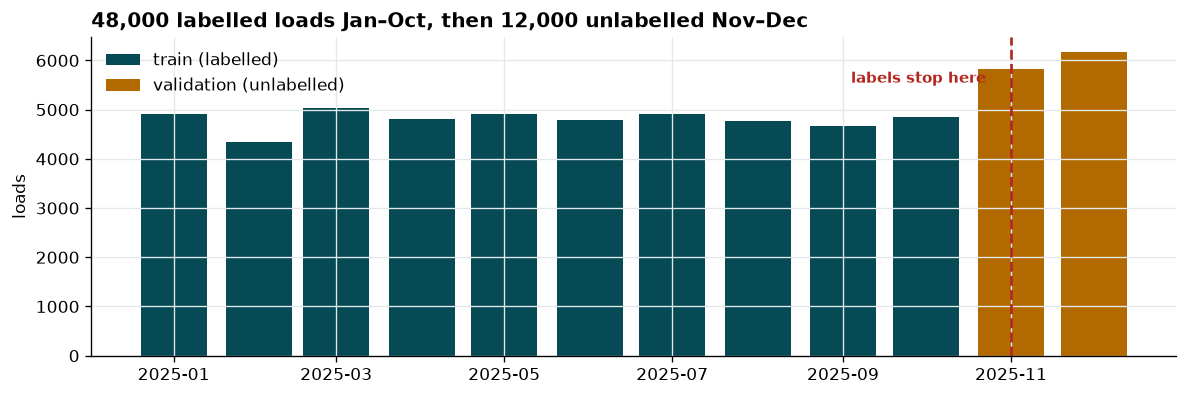

In [2]:
fig, ax = plt.subplots(figsize=(10, 3.4))
counts = pd.concat([
    train.assign(split="train"),
    valid.assign(split="validation"),
]).groupby([pd.Grouper(key="date", freq="MS"), "split"]).size().unstack(fill_value=0)

ax.bar(counts.index, counts.get("train", 0), width=24, color=TEAL, label="train (labelled)")
ax.bar(counts.index, counts.get("validation", 0), width=24, color=AMBER, label="validation (unlabelled)")
ax.axvline(pd.Timestamp("2025-11-01"), color=RUST, linestyle="--", linewidth=1.6)
ax.annotate("labels stop here", xy=(pd.Timestamp("2025-11-01"), counts.values.max() * 0.9),
            xytext=(-96, 0), textcoords="offset points", color=RUST, fontweight="bold", fontsize=9)
ax.set_ylabel("loads")
ax.set_title("48,000 labelled loads Jan–Oct, then 12,000 unlabelled Nov–Dec", loc="left", fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

<a id="2"></a>
## 2. The target

`posted_rate` is the total dollars paid for a load, so it scales with trip length, and
its correlation with `distance` is 0.91. Dividing it out gives rate-per-mile, which is the
quantity actually worth modelling. Its tail is long: a median of \$2.15/mile, but the
top 0.7% of loads run past \$4 and reach \$14.

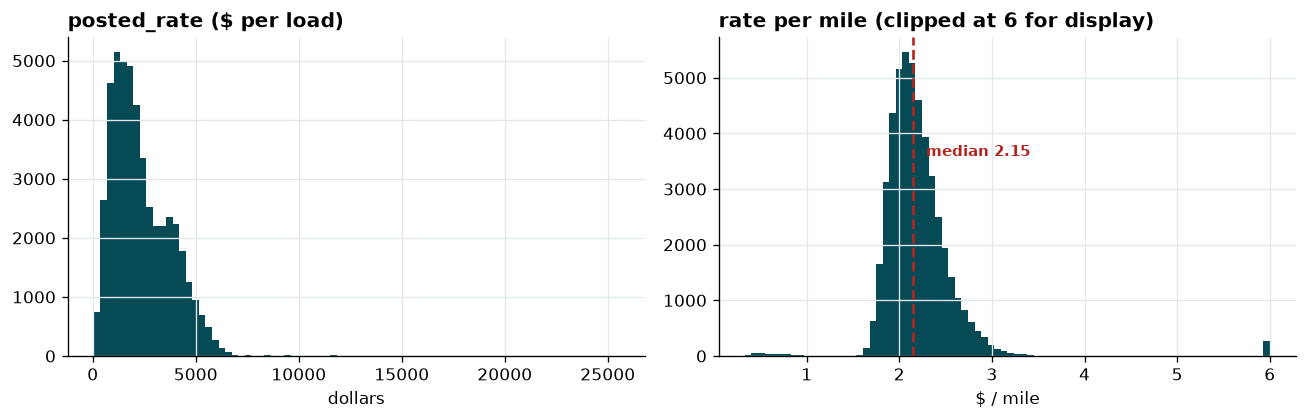

correlation, distance vs posted_rate : 0.909
share of loads above $4/mile         : 0.71%
max rate per mile                    : $14.13


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].hist(train.posted_rate, bins=80, color=TEAL)
axes[0].set_title("posted_rate ($ per load)", loc="left", fontweight="bold")
axes[0].set_xlabel("dollars")

axes[1].hist(train.rpm.clip(upper=6), bins=80, color=TEAL)
axes[1].axvline(train.rpm.median(), color=RUST, linestyle="--", linewidth=1.6)
axes[1].annotate(f"median {train.rpm.median():.2f}", xy=(train.rpm.median(), 0),
                 xytext=(8, 120), textcoords="offset points", color=RUST, fontweight="bold", fontsize=9)
axes[1].set_title("rate per mile (clipped at 6 for display)", loc="left", fontweight="bold")
axes[1].set_xlabel("$ / mile")
plt.tight_layout()
plt.show()

print(f"correlation, distance vs posted_rate : {train.distance.corr(train.posted_rate):.3f}")
print(f"share of loads above $4/mile         : {(train.rpm > 4).mean():.2%}")
print(f"max rate per mile                    : ${train.rpm.max():.2f}")

<a id="3"></a>
## 3. `quote_signal`: the finding that reframes the task

A correlation matrix says `quote_signal` is worthless: its correlation with
`posted_rate` is **−0.04**. That is misleading. The column is a dollars-per-mile quote,
so it acts *multiplicatively* with distance, and the heavy tail crushes the linear
correlation.

Multiply it out and the picture inverts.

In [4]:
baseline = train.distance * train.quote_signal
ratio = train.posted_rate / baseline
ape = (baseline - train.posted_rate).abs() / train.posted_rate * 100

print(f"correlation, quote_signal vs posted_rate : {train.quote_signal.corr(train.posted_rate):+.3f}   <- looks useless")
print()
print("but  predicted = distance x quote_signal, with no model at all:")
print(f"    within  2% of the actual rate : {(ratio.sub(1).abs() <= 0.02).mean():.1%} of loads")
print(f"    within 10% of the actual rate : {(ratio.sub(1).abs() <= 0.10).mean():.1%} of loads")
error = (baseline - train.posted_rate).abs()
print(f"    median absolute % error        : {ape.median():>8.2f}%")
print(f"    mean absolute % error  (MAPE)  : {ape.mean():>8.2f}%")
print(f"    median absolute error          : ${error.median():>8,.2f}")
print(f"    mean absolute error    (MAE)   : ${error.mean():>8,.2f}")

correlation, quote_signal vs posted_rate : -0.040   <- looks useless

but  predicted = distance x quote_signal, with no model at all:
    within  2% of the actual rate : 49.9% of loads
    within 10% of the actual rate : 66.9% of loads
    median absolute % error        :     2.02%
    mean absolute % error  (MAPE)  :    11.37%
    median absolute error          : $   55.55
    mean absolute error    (MAE)   : $  232.26


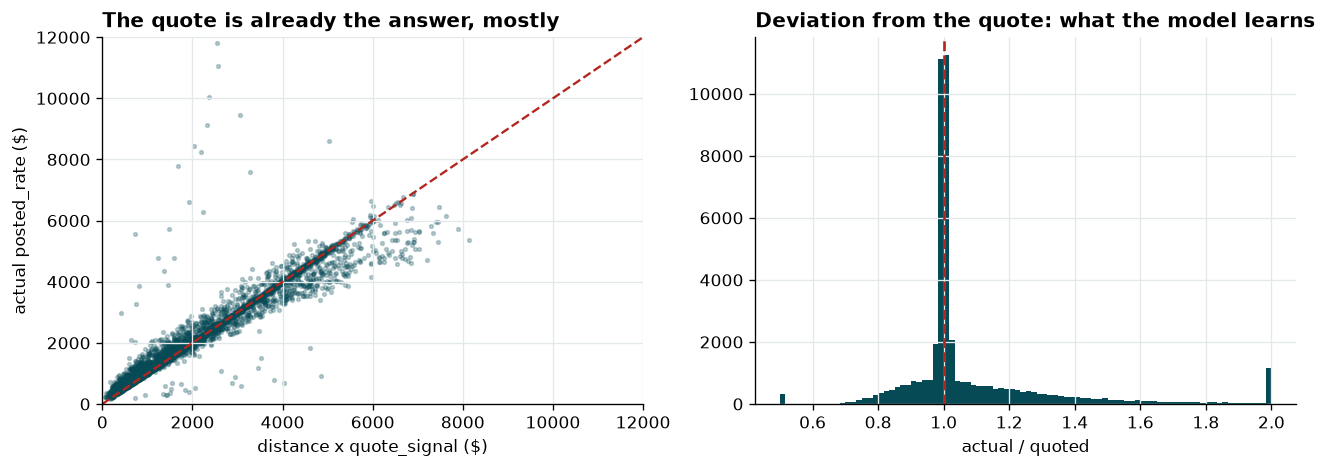

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

sample = train.sample(4000, random_state=0)
axes[0].scatter(sample.distance * sample.quote_signal, sample.posted_rate,
                s=5, alpha=0.25, color=TEAL)
limit = 12000
axes[0].plot([0, limit], [0, limit], color=RUST, linewidth=1.4, linestyle="--")
axes[0].set_xlim(0, limit); axes[0].set_ylim(0, limit)
axes[0].set_xlabel("distance x quote_signal ($)")
axes[0].set_ylabel("actual posted_rate ($)")
axes[0].set_title("The quote is already the answer, mostly", loc="left", fontweight="bold")

axes[1].hist(ratio.clip(0.5, 2.0), bins=90, color=TEAL)
axes[1].axvline(1.0, color=RUST, linestyle="--", linewidth=1.6)
axes[1].set_xlabel("actual / quoted")
axes[1].set_title("Deviation from the quote: what the model learns", loc="left", fontweight="bold")
plt.tight_layout()
plt.show()

Loads scatter on *both* sides of the line (57.8% above, 42.2% below), so the quote is a
central estimate, not a floor. What is lopsided is how far each side reaches: the 1st
percentile sits 27% below the quote, the 99th sits 155% above, and the extreme runs to
11.4×. Skew is **6.64**.

That is why the model predicts `log(posted_rate / (distance × quote_signal))` rather
than the rate itself. The **ratio** means it only has to learn the deviation from a
quote that is already within 2% half the time. The **log** does two things: it makes a
doubling and a halving equally wrong (±0.69, rather than +1.00 against −0.50), and it
stops the worst load steering the fit: under squared error that load outweighs a
typical one by 10,757× on the raw ratio but only 651× in log space. Skew falls from
6.64 to 0.96.

<a id="4"></a>
## 4. Data quality

Three issues, all in the load-attribute columns rather than the target.

In [6]:
issues = pd.DataFrame([
    {"issue": "negative weight",
     "train": int((train_raw.weight < 0).sum()), "validation": int((valid_raw.weight < 0).sum()),
     "handling": "sign error - abs(), no flag"},
    {"issue": "missing weight",
     "train": int(train_raw.weight.isna().sum()), "validation": int(valid_raw.weight.isna().sum()),
     "handling": "imputed in RateModel.fit from TRAIN medians"},
    {"issue": "missing market_index",
     "train": int(train_raw.market_index.isna().sum()), "validation": int(valid_raw.market_index.isna().sum()),
     "handling": "filled from the same date's mean"},
])
display(issues)

# Negative weights are sign errors, not corrupt records: their magnitudes match the rest.
negative = train_raw.loc[train_raw.weight < 0, "weight"].abs()
positive = train_raw.loc[train_raw.weight > 0, "weight"]
print(f"median |weight| among negatives : {negative.median():,.0f}")
print(f"median  weight  among positives : {positive.median():,.0f}")
print("-> same distribution, so the magnitude is trustworthy and only the sign is wrong")

,issue,train,validation,handling
0,negative weight,292,145,"sign error - abs(), no flag"
1,missing weight,300,165,imputed in RateModel.fit from TRAIN medians
2,missing market_index,374,249,filled from the same date's mean


median |weight| among negatives : 31,822
median  weight  among positives : 31,494
-> same distribution, so the magnitude is trustworthy and only the sign is wrong


<a id="5"></a>
## 5. `market_index`: a daily series wearing a per-load disguise

On a day with ~157 loads there are ~155 distinct `market_index` values, which looks
like a per-load attribute. It is not. Decomposing the variance shows the date explains
almost all of it.

In [7]:
daily = train.groupby("date").market_index.transform("mean")
grand = train.market_index.mean()
explained = ((daily - grand) ** 2).sum() / ((train.market_index - grand) ** 2).sum()

print(f"variance explained by date alone : {explained:.1%}")
print(f"left over as within-day scatter  : {1 - explained:.1%}")
print()
print(f"std of the daily means  : {train.groupby('date').market_index.mean().std():.4f}")
print(f"avg within-day std      : {train.groupby('date').market_index.std().mean():.4f}")

# The leftover correlates with nothing about the load.
deviation = train.market_index - daily
print("\ncorrelation of the within-day leftover with:")
for column in ["distance", "weight", "quote_signal", "posted_rate"]:
    subset = train.dropna(subset=[column])
    print(f"    {column:13s} {np.corrcoef(subset[column], deviation[subset.index])[0, 1]:+.4f}")

variance explained by date alone : 97.8%
left over as within-day scatter  : 2.2%

std of the daily means  : 0.1665
avg within-day std      : 0.0248

correlation of the within-day leftover with:
    distance      -0.0041
    weight        +0.0093
    quote_signal  +0.0107
    posted_rate   +0.0024


The date accounts for almost all of this column, and the 2.2% it does not account for
predicts nothing. So averaging a date's loads recovers that day's market level rather
than some property of whichever loads happened to be sampled.

**That is what makes the December chart possible.** `december_chart_inputs.csv` ships
without `market_index`, but `validation.csv` covers all 31 December days, so each date's
level can be read straight off it. Without this finding there would be no defensible
market input for December, and the chart would flatten to a single value across the
whole month.

<a id="6"></a>
## 6. Distribution shift

`market_index` does not merely move between the two windows. Validation never reaches
the upper half of training's range, so a large share of the training rows sit in market
conditions the model will never be asked to predict in. Anything it learns about that
upper range is unusable.

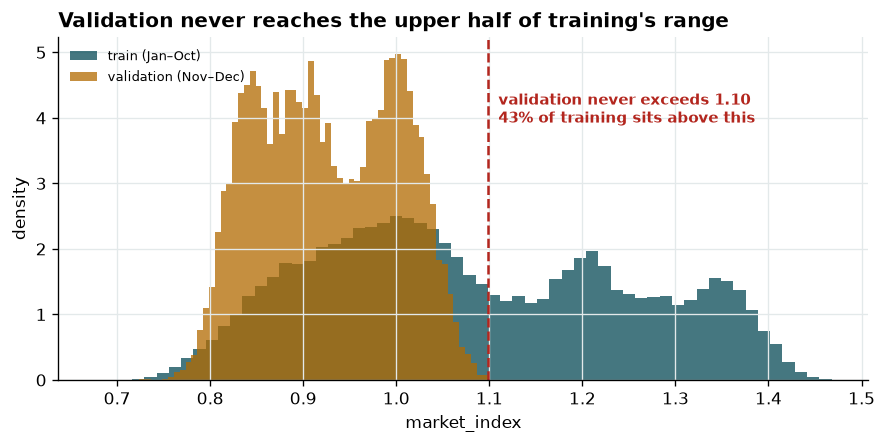

train      mean 1.083   range 0.68–1.47
validation mean 0.927   range 0.72–1.10

share of training above validation's maximum: 42.8%


In [8]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))

ax.hist(train.market_index, bins=60, alpha=0.75, color=TEAL, label="train (Jan–Oct)", density=True)
ax.hist(valid.market_index, bins=60, alpha=0.75, color=AMBER, label="validation (Nov–Dec)", density=True)
ax.axvline(valid.market_index.max(), color=RUST, linestyle="--", linewidth=1.5)
ax.annotate(f"validation never exceeds {valid.market_index.max():.2f}\n"
            f"{(train.market_index > valid.market_index.max()).mean():.0%} of training sits above this",
            xy=(valid.market_index.max(), 4.4), xytext=(6, 0), textcoords="offset points",
            fontsize=9, color=RUST, fontweight="bold", va="top")
ax.set_xlabel("market_index")
ax.set_ylabel("density")
ax.set_title("Validation never reaches the upper half of training's range",
             loc="left", fontweight="bold")
ax.legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

print(f"train      mean {train.market_index.mean():.3f}   range {train.market_index.min():.2f}–{train.market_index.max():.2f}")
print(f"validation mean {valid.market_index.mean():.3f}   range {valid.market_index.min():.2f}–{valid.market_index.max():.2f}")
print(f"\nshare of training above validation's maximum: "
      f"{(train.market_index > valid.market_index.max()).mean():.1%}")

<a id="7"></a>
## 7. Cold start: eight cities appear only at prediction time

Any encoding built on city *names* meets categories it has never seen.

In [9]:
train_cities = set(train.pickup) | set(train.delivery)
valid_cities = set(valid.pickup) | set(valid.delivery)
unseen = sorted(valid_cities - train_cities)

print(f"cities in train      : {len(train_cities)}")
print(f"cities in validation : {len(valid_cities)}")
print(f"unseen at prediction : {len(unseen)} -> {', '.join(unseen)}")

affected = valid[valid.pickup.isin(unseen) | valid.delivery.isin(unseen)]
print(f"\nvalidation loads touching an unseen city: {len(affected):,} ({len(affected) / len(valid):.1%})")
print("\nCoordinates are supplied for these cities, and are fixed per city across the")
print("dataset - so geography-derived features generalise where names cannot.")

cities in train      : 64
cities in validation : 72
unseen at prediction : 8 -> Allentown, Charlotte, Chicago, Jackson, Knoxville, Laredo, Norfolk, San Diego

validation loads touching an unseen city: 1,447 (12.1%)

Coordinates are supplied for these cities, and are fixed per city across the
dataset - so geography-derived features generalise where names cannot.


<a id="8"></a>
## 8. Equipment: the quote does not price it

`quote_signal` is essentially flat across trailer types, but realised rates are not.
The gap is not a uniform shift: the *typical* load of every type lands on its quote, and
what changes is how often a load escapes it.

In [10]:
comparison = pd.DataFrame({
    "mean quote_signal": train.groupby("equipment").quote_signal.mean(),
    "median actual $/mile": train.groupby("equipment").rpm.median(),
})
residual = train.rpm / train.quote_signal
core = residual.between(0.5, 2.0)
comparison["median actual/quote"] = residual[core].groupby(train.equipment[core]).median()
comparison["share paying >20% over quote"] = (residual[core] > 1.2).groupby(train.equipment[core]).mean()
display(comparison.round(4))

,mean quote_signal,median actual $/mile,median actual/quote,share paying >20% over quote
equipment,,,,
Dry Van,2.0474,2.0462,0.9999,0.0994
Flatbed,2.0795,2.2197,1.0068,0.1947
Reefer,2.0840,2.3115,1.0102,0.2627


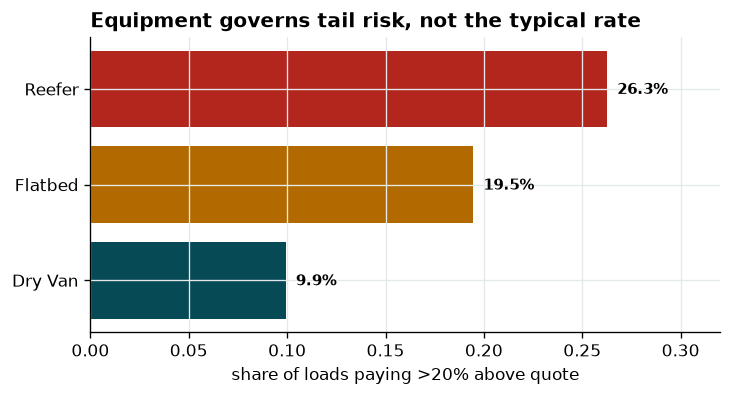

In [11]:
fig, ax = plt.subplots(figsize=(6.2, 3.4))
share = (residual[core] > 1.2).groupby(train.equipment[core]).mean().sort_values()
ax.barh(share.index, share.values, color=[TEAL, AMBER, RUST])
for name, value in share.items():
    ax.annotate(f"{value:.1%}", xy=(value, name), xytext=(6, -3),
                textcoords="offset points", fontweight="bold", fontsize=9)
ax.set_xlim(0, 0.32)
ax.set_xlabel("share of loads paying >20% above quote")
ax.set_title("Equipment governs tail risk, not the typical rate", loc="left", fontweight="bold")
plt.tight_layout()
plt.show()

A Reefer is **2.6×** as likely as a Dry Van to blow past its quote. That is an argument
for a tail-aware loss or for modelling the deviation separately, not for a simple
per-equipment offset.

The ordering in that table also decides how the column is encoded. By median rate the
types run Dry Van < Flatbed < Reefer. A tree can isolate a category from an integer code,
but only as a contiguous run, so the code's *order* determines which single splits exist:
arbitrary codes of Dry Van=0, Reefer=1, Flatbed=2 put the cheapest type and the dearest on
the same side of one available split, and cost **+1.74 MAE (±0.26)**, the same sign in
all three folds. Reordering the codes by price recovers most of that but not all (+0.80,
sign varying by fold). The model uses one indicator column per type, which assumes no
ordering at all.

<a id="9"></a>
## 9. Temporal structure

Enough autocorrelation to invalidate random cross-validation, and a clear weekly cycle.

,daily median $/mile,daily market level
lag 1,0.844,0.927
lag 2,0.771,0.768
lag 3,0.723,0.640
lag 7,0.789,0.969
lag 14,0.704,0.924
lag 30,0.470,0.541


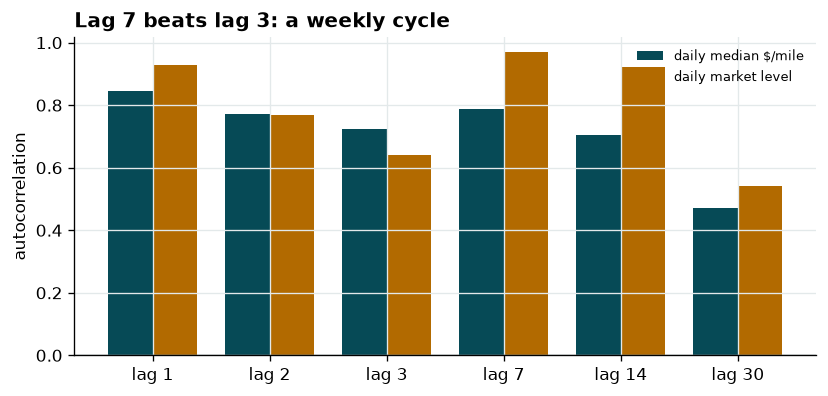

lag-1 autocorrelation of daily $/mile : +0.844
-> a shuffled split trains on Tuesday and tests on Wednesday, which share a market level


In [12]:
daily_rpm = train.groupby("date").rpm.median()
daily_market = train.groupby("date").market_index.mean()

lags = [1, 2, 3, 7, 14, 30]
acf = pd.DataFrame({
    "daily median $/mile": [daily_rpm.autocorr(lag) for lag in lags],
    "daily market level": [daily_market.autocorr(lag) for lag in lags],
}, index=[f"lag {lag}" for lag in lags])
display(acf.round(3))

fig, ax = plt.subplots(figsize=(7, 3.4))
width = 0.38
positions = np.arange(len(lags))
ax.bar(positions - width / 2, acf.iloc[:, 0], width, color=TEAL, label=acf.columns[0])
ax.bar(positions + width / 2, acf.iloc[:, 1], width, color=AMBER, label=acf.columns[1])
ax.set_xticks(positions); ax.set_xticklabels(acf.index)
ax.axhline(0, color=SLATE, linewidth=0.8)
ax.set_ylabel("autocorrelation")
ax.set_title("Lag 7 beats lag 3: a weekly cycle", loc="left", fontweight="bold")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

print(f"lag-1 autocorrelation of daily $/mile : {daily_rpm.autocorr(1):+.3f}")
print("-> a shuffled split trains on Tuesday and tests on Wednesday, which share a market level")

<a id="10"></a>
## 10. What this implies

| Finding | Consequence for the model |
|---|---|
| Holdout is forward in time; lag-1 autocorrelation +0.84 | Forward-chaining validation. Random k-fold understates MAE by 37.0% |
| `distance × quote_signal` is within 2% on half the loads | Predict the log ratio against that baseline, not the raw rate |
| Target tail reaches \$14/mile | Log target, so 0.7% of rows do not dominate the loss |
| `market_index` is 97.8% a daily series | Recover the daily level; use it for December, where the column is absent |
| Its range shifts train → validation | Do not lean on the upper half of the learned range |
| 300 loads have no weight recorded | Impute in `fit` from training medians, never in cleaning |
| 8 cities unseen until prediction | Coordinates and a haversine distance, never city names |
| Equipment drives tail risk, not level | One-hot indicators, so the model assumes no ordering and learns the interaction |
| Lag-7 > lag-3 autocorrelation | Day-of-week as a feature, which recurs and so extrapolates into December |

The last two rows are what the December chart tests. Encoding the date as an ordinal or
a month index produces a flat line, because both fall beyond the training horizon; see
`reports/figures/december_encoding_comparison.png` and
[`src/freight_rate/features/temporal.py`](../src/freight_rate/features/temporal.py).

---

# Part II. Feature engineering

<a id="11"></a>
## 11. The feature matrix

Fifteen columns, assembled in three blocks by `src/freight_rate/features/`: load
attributes, geography, and the date. Nothing is here because it is conventional. Every
derived column below either survived an ablation on the forward folds or is a supplied
column passed through untouched.

In [13]:
from freight_rate.features import DateEncoding
from freight_rate.features import build as build_features

# One market-level series, recovered from both files, shared by every model below.
market_levels = market.daily_levels(train, valid)

matrix = build_features(train, DateEncoding.RECURRING, market_levels)
print(f"{matrix.shape[0]:,} rows x {matrix.shape[1]} columns\n")
display(matrix.head(3).T)

48,000 rows x 15 columns



,0,1,2
distance,274.300000,280.500000,967.800000
quote_signal,2.395950,2.433550,1.844910
market_index,0.956840,0.976230,1.009710
is_dry_van,1.000000,0.000000,1.000000
is_reefer,0.000000,1.000000,0.000000
is_flatbed,0.000000,0.000000,0.000000
weight,30658.000000,17555.000000,31721.000000
pickup_lat,38.091220,38.091220,39.223170
pickup_lon,-76.789060,-76.789060,-72.967100
delivery_lat,38.169080,39.223170,44.302960


| Column | Block | Origin | Why it is in the matrix |
|---|---|---|---|
| `distance` | load | supplied | Trip length. Also half of the target's baseline (§17) |
| `quote_signal` | load | supplied | The per-load \$/mile quote. 81% of permutation importance |
| `market_index` | load | supplied, gaps filled | Market conditions on the day of the load |
| `weight` | load | supplied, signs repaired | Cargo weight, after `abs()` on 292 sign errors |
| `is_dry_van`, `is_reefer`, `is_flatbed` | load | derived | One indicator per trailer type (§13) |
| `pickup_lat`, `pickup_lon`, `delivery_lat`, `delivery_lon` | geography | supplied | Lane identity, which `distance` cannot carry |
| `haversine` | geography | derived | Great-circle miles between the two ends |
| `day_of_week` | temporal | derived | The weekly cycle, and it recurs in December |
| `day_of_month` | temporal | derived | Within-month position, also recurring |
| `daily_market_level` | temporal | derived | The date's recovered market level (§5) |

**Why the geography block is four coordinates plus a near-duplicate of `distance`.**
Among Dry Van loads of 300 to 500 miles, lane median rate per mile spans 2.105 to 2.535,
a 20% spread at effectively the same length, and it replicates across split halves at
+0.737. `distance` cannot see that; coordinates can. Dropping them costs **+3.86 MAE
(±0.34)**, the same sign in all three folds.

The haversine correlates 0.9995 with the supplied `distance`, so it is very nearly a
duplicate column, and whether that pays depends on a hyperparameter:

| Setting | Value of keeping `haversine` |
|---|---|
| Every feature offered at each split | −0.09 MAE (±0.13), nothing |
| `max_features` restricted to 8 of 15 | +2.08 MAE (±0.27) to drop it |

Under feature subsampling only some columns are offered at each node, so a second
distance-like column raises the odds that one of them is available. Redundancy stops
being waste and becomes insurance.

**What was tried and is not here.**

| Not in the matrix | Measured reason |
|---|---|
| `log(distance)` | Trees split on thresholds, so any monotone transform gives identical splits |
| Bearing, `dlat`, `dlon` | +0.51 MAE (±0.23), and the sign varies by fold |
| sin/cos day-of-week | +0.58 MAE (±0.15) against the plain integer |
| `date_ordinal`, `month` | +44.25 MAE, and it flattens the December chart (§14) |
| A missing-weight flag | Rows missing a weight price like the rest: median \$/mile 2.1176 against 2.1456, Mann-Whitney p = 0.234 |
| City name categories | Eight cities appear only at prediction time (§7, §15) |

<a id="12"></a>
## 12. What each feature is worth

Permutation importance on the last forward fold: shuffle one column of the held-out
matrix, refit nothing, and measure how much worse the prediction gets.

fitted on train->08  test 09-10: 38,477 loads, scored on 9,523


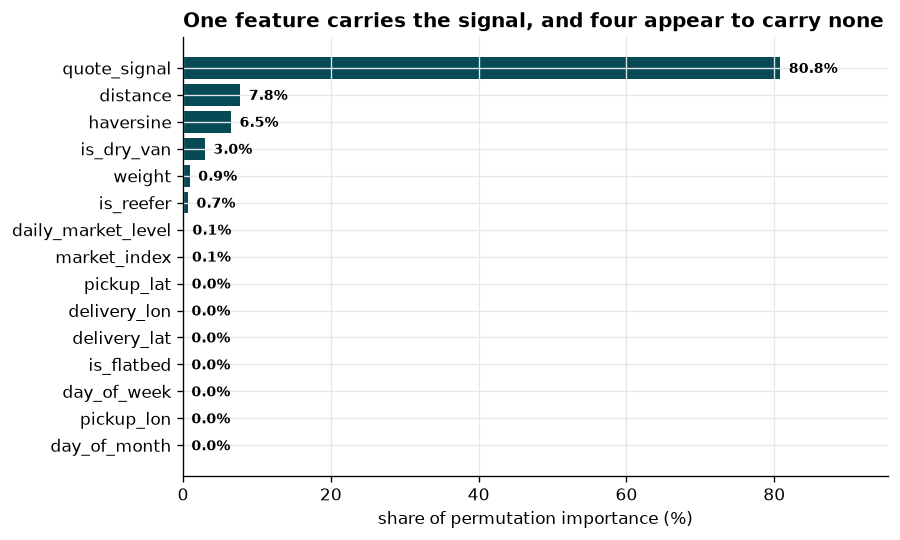

,importance (log-ratio R²),share %
quote_signal,0.64392,80.84
distance,0.06187,7.77
haversine,0.05196,6.52
is_dry_van,0.02365,2.97
weight,0.00737,0.92
is_reefer,0.00549,0.69
daily_market_level,0.00115,0.14
market_index,0.00064,0.08
pickup_lat,0.00035,0.04
delivery_lon,0.00012,0.01


In [14]:
from sklearn.inspection import permutation_importance

from freight_rate.modeling import RateModel, forward_folds, target

last_fold = list(forward_folds(train))[-1]
print(f"fitted on {last_fold.label}: {len(last_fold.train):,} loads, "
      f"scored on {len(last_fold.test):,}")

fitted = RateModel(DateEncoding.RECURRING, market_levels).fit(last_fold.train)
held_out = fitted.design_matrix(last_fold.test)

permuted = permutation_importance(
    fitted.estimator, held_out, target.encode(last_fold.test),
    n_repeats=5, random_state=0, n_jobs=-1,
)
importance = pd.Series(permuted.importances_mean, index=held_out.columns).sort_values()
share = importance.clip(lower=0) / importance.clip(lower=0).sum() * 100

fig, ax = plt.subplots(figsize=(7.6, 4.6))
ax.barh(importance.index, share.to_numpy(),
        color=[TEAL if value >= 0.5 else SLATE for value in share])
for name, value in share.items():
    ax.annotate(f"{value:.1f}%", xy=(value, name), xytext=(5, -3),
                textcoords="offset points", fontsize=8.5, fontweight="bold")
ax.set_xlim(0, share.max() * 1.18)
ax.set_xlabel("share of permutation importance (%)")
ax.set_title("One feature carries the signal, and four appear to carry none",
             loc="left", fontweight="bold")
plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "importance (log-ratio R²)": importance.round(5),
    "share %": share.round(2),
}).sort_values("share %", ascending=False))

**`quote_signal` dominates, and that shapes two later decisions.** It is why the model
predicts a correction to the quote rather than the rate itself (§17), and why
`max_features` is restricted to 8 of 15: with one feature this strong, a forest that
offers every column at every split puts it at the root of all 400 trees and the trees end
up correlated, which is the one thing averaging cannot repair (§18).

**The four coordinates score about 0%, and that reading is wrong.** It is the known
failure of permutation importance under correlated features: permuting `pickup_lat`
leaves three other coordinates that still pin the lane down, so each looks worthless
alone while the four together are worth +3.86 MAE. Importance measures what one column
adds *given the others*; an ablation measures what a block is worth. Where the two
disagree here, the ablation is what the feature set rests on.

**`haversine` at 6.5% next to `distance` at 7.8% is the same effect, read the other way.**
Two columns that correlate 0.9995 split the credit between them rather than one taking it
all, which is exactly what should happen when `max_features` means only some columns are
offered at each node. Neither is redundant when only one of them is on the table.

---

# Part III. Encoding

Three columns need a representation chosen for them, and each choice was measured rather
than assumed.

<a id="13"></a>
## 13. Equipment: one indicator per type

A tree can isolate a category from an integer code, but only as a contiguous run, so the
coding's *order* decides which single splits exist. By median rate the types run
Dry Van < Flatbed < Reefer, and arbitrary codes of Dry Van=0, Reefer=1, Flatbed=2 put the
cheapest and the dearest on the same side of one available split.

| Encoding | Cost against indicators |
|---|---|
| Arbitrary integer codes | **+1.74 MAE (±0.26)**, same sign in all three folds |
| Codes ordered by median rate | +0.80 MAE, sign varies by fold |
| One indicator per type | baseline, and needs no ordering to justify |

Reordering recovers most of the gap but not all of it, so the ordering was most of the
problem and the representation is the rest. Indicators assume nothing.

In [15]:
display(train[["equipment"]].head(4).join(matrix.filter(like="is_").head(4)))
print(matrix.filter(like="is_").sum().astype(int).to_string())

# One-hot would encode an unseen trailer type as all-zeros, indistinguishable from a
# type the model knows. assembly.build raises instead, so it cannot reach a prediction.
try:
    build_features(train.head(3).assign(equipment="Conestoga"),
                   DateEncoding.RECURRING, market_levels)
except ValueError as error:
    print(f"\nguard fired: {error}")

,equipment,is_dry_van,is_reefer,is_flatbed
0,Dry Van,1.0,0.0,0.0
1,Reefer,0.0,1.0,0.0
2,Dry Van,1.0,0.0,0.0
3,Dry Van,1.0,0.0,0.0


is_dry_van    27202
is_reefer     12045
is_flatbed     8753

guard fired: unmapped equipment types: ['Conestoga']


<a id="14"></a>
## 14. Dates: the encoding the December chart turns on

Training ends 2025-10-31 and the chart asks for December. A tree cannot extrapolate past
a threshold it never saw: it clamps the value into the last region it learned. So the
question for every date feature is whether December's values fall inside the range the
model was trained on.

In [16]:
from freight_rate.features import temporal

december_days = pd.Series(pd.date_range("2025-12-01", "2025-12-31"))

ordinal_train = temporal.build_ordinal(train.date)
ordinal_december = temporal.build_ordinal(december_days)
recurring_train = temporal.build_recurring(train.date, market_levels)
recurring_december = temporal.build_recurring(december_days, market_levels)


def coverage(name, learned, asked):
    return [
        {"encoding": name, "feature": column,
         "training range": f"{learned[column].min():.2f} to {learned[column].max():.2f}",
         "December range": f"{asked[column].min():.2f} to {asked[column].max():.2f}",
         "December inside it?": bool(asked[column].between(
             learned[column].min(), learned[column].max()).all())}
        for column in learned.columns
    ]


display(pd.DataFrame(
    coverage("ordinal", ordinal_train, ordinal_december)
    + coverage("recurring", recurring_train, recurring_december)
))

,encoding,feature,training range,December range,December inside it?
0,ordinal,date_ordinal,0.00 to 303.00,334.00 to 364.00,False
1,ordinal,month,1.00 to 10.00,12.00 to 12.00,False
2,recurring,day_of_week,0.00 to 6.00,0.00 to 6.00,True
3,recurring,day_of_month,1.00 to 31.00,1.00 to 31.00,True
4,recurring,daily_market_level,0.77 to 1.40,0.83 to 1.04,True


Both ordinal features fall outside every split the model ever learned, and all three
recurring features land inside. That is the mechanism. Here is what it costs, measured on
the forward folds that §19 unpacks: each fold tests a period beyond its own training
horizon, which is the same extrapolation December demands.

In [17]:
from freight_rate.evaluation import metrics


def recurring_model() -> RateModel:
    return RateModel(DateEncoding.RECURRING, market_levels)


def ordinal_model() -> RateModel:
    return RateModel(DateEncoding.ORDINAL, market_levels)


# Kept for Part V: the recurring row is the headline validation result, not a side
# experiment, so it is computed once here and reused rather than refitted.
forward = metrics.evaluate_splits(forward_folds(train), recurring_model)
ordinal = metrics.evaluate_splits(forward_folds(train), ordinal_model)

comparison = pd.concat([
    metrics.summarise(ordinal, "ordinal (date_ordinal + month)"),
    metrics.summarise(forward, "recurring (day-of-week + market level)"),
], ignore_index=True)
display(comparison.round(2))
print(f"Ordinal costs {comparison.loc[0, 'MAE'] / comparison.loc[1, 'MAE'] - 1:.0%} MAE.")

,strategy,MAE,RMSE,MAPE %,median APE %
0,ordinal (date_ordinal + month),173.18,650.42,7.61,4.26
1,recurring (day-of-week + market level),128.93,636.27,5.70,2.39


Ordinal costs 34% MAE.


<a id="15"></a>
## 15. Geography: coordinates, never city names

§7 found eight cities that appear only in `validation.csv`. Any encoding built on city
*names* meets an unseen category at prediction time; coordinates do not, because they are
supplied for every city and are fixed per city across the dataset.

In [18]:
from freight_rate.features import geography

lookup = geography.city_coordinates(train, valid)
print(f"{len(lookup)} cities, from stacking both ends of every load in both files")
display(lookup.head(4))

# Fixed per city, and identical whether the city is an origin or a destination: that is
# the only property these features need. (The coordinates are not real geography.)
stacked = pd.concat([
    train[["pickup", "pickup_lat"]].rename(columns={"pickup": "city", "pickup_lat": "lat"}),
    train[["delivery", "delivery_lat"]].rename(columns={"delivery": "city", "delivery_lat": "lat"}),
])
print(f"\ncities carrying more than one latitude: {(stacked.groupby('city').lat.nunique() > 1).sum()}")

# This lookup is also what lets december_chart_inputs.csv, which ships city names and no
# coordinates at all, reach the model (§24).

72 cities, from stacking both ends of every load in both files


,lat,lon
city,,
Albany,43.96975,-71.05842
Albuquerque,35.39918,-109.59792
Allentown,40.01684,-73.80889
Amarillo,33.17137,-104.36789



cities carrying more than one latitude: 0


---

# Part IV. Missing values

<a id="16"></a>
## 16. Where each gap is filled, and why the placement is the point

Three data-quality issues, counted in §4. Two of them are gaps, and they are filled in
different places on purpose.

In [19]:
display(pd.DataFrame({
    "raw train": train_raw[["weight", "market_index"]].isna().sum(),
    "raw validation": valid_raw[["weight", "market_index"]].isna().sum(),
    "after cleaning.clean": train[["weight", "market_index"]].isna().sum(),
}))

remaining = matrix.isna().sum()
print("NaN still present in the 15-column model matrix, for fit() to deal with:")
print(remaining[remaining > 0].to_string())

pooled_matrix = build_features(pd.concat([train, valid]), DateEncoding.RECURRING, market_levels)
print(f"\nfill value from January-October only : {matrix.weight.median():,.0f} lb"
      "   <- what fit() stores")
print(f"fill value if pooled with Nov-Dec    : {pooled_matrix.weight.median():,.0f} lb"
      "   <- never used")

,raw train,raw validation,after cleaning.clean
weight,300,165,300
market_index,374,249,0


NaN still present in the 15-column model matrix, for fit() to deal with:
weight    300

fill value from January-October only : 31,496 lb   <- what fit() stores
fill value if pooled with Nov-Dec    : 31,467 lb   <- never used


**Where each repair happens, and why it matters.** The two `weight` issues and the
`market_index` gaps are fixed in different places, on purpose.

`market_index` is filled during cleaning, from the mean of its own date. Section 5 below
shows why that is a recovery rather than a guess: 97.8% of the column's variance is
explained by date alone. A row's own date is available at prediction time, so nothing
about the future is used.

**`weight` is different.** `RandomForestRegressor` cannot accept a missing value, so the
300 training and 165 validation blanks must be filled with something. The fill value is
the median weight, 31,496 lb, and it is computed **only from the January–October rows**,
then reused unchanged on November and December.

That placement is the whole point. Imputing during cleaning would take the median across
all 60,000 rows, which lets the November–December loads help set the number used to fill
their own blanks. The gap is small here (31,496 lb against 31,467 lb pooled, a difference
of 29 lb) but the habit is what generalises: a fill value is a *fitted parameter*, so it
belongs in `fit`, learned from training data alone.

So imputation lives in `RateModel.fit`, which stores it, and `RateModel.predict` only
reads it back. `predict` never computes a median, which means it cannot peek even by
accident.

Filling with a median is safe here because the rows missing a weight are not otherwise
unusual: they price like the rest (median rate/mile 2.1176 against 2.1456, Mann-Whitney
p = 0.234) and carry the same equipment mix.

The cell below demonstrates that rather than asserting it: blank every weight in a
held-out block and see which median comes back.

In [20]:
demonstration = RateModel(DateEncoding.RECURRING, market_levels).fit(last_fold.train)

# Blank every weight in the held-out block, so whatever comes back is purely the fill.
blanked = last_fold.test.assign(weight=np.nan)
filled = demonstration.design_matrix(blanked).weight.unique()

print(f"median weight in the fold's TRAINING rows : {last_fold.train.weight.median():>9,.0f} lb")
print(f"median weight in the fold's TEST rows     : {last_fold.test.weight.median():>9,.0f} lb")
print(f"what predict() actually fills with        : {filled[0]:>9,.0f} lb "
      f"({len(filled)} distinct value)")
print("\nThe fill is fixed at fit time, so the rows being predicted cannot influence it.")

median weight in the fold's TRAINING rows :    31,472 lb
median weight in the fold's TEST rows     :    31,622 lb
what predict() actually fills with        :    31,472 lb (1 distinct value)

The fill is fixed at fit time, so the rows being predicted cannot influence it.


---

# Part V. Training and testing

<a id="17"></a>
## 17. The target: predict the correction, not the rate

§3 found that `distance × quote_signal` already lands within 2% of the actual rate on
half the training rows. So the model predicts
`log(posted_rate / (distance × quote_signal))` and only has to learn the deviation.

The ratio removes the part that is already known. The log does two further things: it
makes a doubling and a halving equally wrong (±0.69 rather than +1.00 against −0.50), and
it stops the worst load steering a squared-error fit.

In [21]:
quote = target.baseline(train)
encoded = target.encode(train)
restored = target.decode(encoded.to_numpy(), train)

print(f"skew of  posted_rate / quote  : {(train.posted_rate / quote).skew():>6.2f}")
print(f"skew of  log(that ratio)      : {encoded.skew():>6.2f}")
print(f"\nlargest round-trip error, encode then decode: "
      f"${np.abs(restored - train.posted_rate).max():.2e}")
display(pd.DataFrame({
    "posted_rate": train.posted_rate.head(3),
    "quote baseline": quote.head(3),
    "log ratio (what the forest fits)": encoded.head(3),
}))

skew of  posted_rate / quote  :   6.64
skew of  log(that ratio)      :   0.96

largest round-trip error, encode then decode: $3.64e-12


,posted_rate,quote baseline,log ratio (what the forest fits)
0,645.41,657.209085,-0.018116
1,679.97,682.610775,-0.003876
2,1802.54,1785.503898,0.009496


<a id="18"></a>
## 18. The estimator: RandomForest, chosen on forward-chained MAE

Thirteen configurations were benchmarked at sensible defaults, then the three leading
families were tuned over comparable grids, roughly 130 fits in all. Only the winner is
carried through this notebook; the full sweep is in `README.md`. The five the decision
turned on, each at its best known setting:

| Model | MAE | Chart shape vs real prices |
|---|---|---|
| ExtraTrees (tuned) | **128.28** | +0.153 |
| **RandomForest (tuned)** | 128.93 | +0.233 |
| LightGBM (tuned) | 131.06 | +0.237 |
| HistGradientBoosting (tuned) | 135.57 | +0.204 |
| ElasticNet (tuned) | 148.23 | **+0.382** |

ExtraTrees has the lower pooled MAE, by \$0.64 (±0.43), but the sign varies by fold
(−3.41, +4.43, −2.97): much better on folds 1 and 3, clearly worse on fold 2, the hardest
block. An edge that reverses on one of three time windows will not carry into an unseen
month, so RandomForest takes it on stability rather than on average. Against boosting the
margin is not close: RandomForest beats HistGradientBoosting by \$6.64 (±0.61), the same
sign in all three folds.

In [22]:
from freight_rate.config import CONFIG

for name, value in CONFIG.model.as_kwargs().items():
    print(f"    {name:18s} {value}")

    n_estimators       400
    max_features       8
    min_samples_leaf   20
    n_jobs             -1
    oob_score          False
    random_state       0


**`max_features=8` of 15 is the one that mattered.** sklearn defaults it to every column,
so with `quote_signal` at 81% of permutation importance every tree splits on it first and
the forest ends up correlated. Restricting it was the single largest win in the search,
and feature subsampling was the largest lever for every tree family tried, the one tuning
result that generalised.

`min_samples_leaf=20` survived its own sweep (10 and 40 are both worse), 400 trees is
where more stops helping, and `absolute_error`, `friedman_mse`, `ccp_alpha`, `max_depth`
and `max_samples` were all tried without a gain that held across folds. `max_features` is
an integer rather than a fraction on purpose: as a float sklearn takes
`int(fraction × n_features)`, so 0.55 and 0.6 can mean the same thing while the fraction
reads more precise than it is.

<a id="19"></a>
## 19. Forward chaining, and what a shuffled split would have claimed

The real task trains on January to October and predicts November and December: a
contiguous block beyond the training horizon. Each fold reproduces that shape.

In [23]:
from freight_rate.modeling import random_folds

display(pd.DataFrame([
    {"fold": fold.label, "train": f"{fold.train_start} to {fold.train_end}",
     "test": f"{fold.test_start} to {fold.test_end}"}
    for fold in CONFIG.folds
]))

print("FORWARD CHAINING (honest)")
display(forward.round(2))

print("RANDOM K-FOLD (invalid here, shown to quantify the optimism)")
shuffled = metrics.evaluate_splits(random_folds(train), recurring_model)
display(shuffled.round(2))

summary = pd.concat([
    metrics.summarise(forward, "forward chaining (honest)"),
    metrics.summarise(shuffled, "random k-fold (optimistic)"),
], ignore_index=True)
display(summary.round(2))
honest, optimistic = summary.loc[0, "MAE"], summary.loc[1, "MAE"]
print(f"Random k-fold understates MAE by ${honest - optimistic:,.2f} "
      f"({honest / optimistic - 1:.1%} optimistic).")

,fold,train,test
0,train->04 test 05-06,2025-01-01 to 2025-04-30,2025-05-01 to 2025-06-30
1,train->06 test 07-08,2025-01-01 to 2025-06-30,2025-07-01 to 2025-08-31
2,train->08 test 09-10,2025-01-01 to 2025-08-31,2025-09-01 to 2025-10-31


FORWARD CHAINING (honest)


,fold,n_train,n_test,MAE,RMSE,MAPE %,median APE %
0,train->04 test 05-06,19110,9696,117.87,632.96,4.98,2.05
1,train->06 test 07-08,28806,9671,150.30,637.35,7.05,3.00
2,train->08 test 09-10,38477,9523,118.61,638.51,5.08,2.12


RANDOM K-FOLD (invalid here, shown to quantify the optimism)


,fold,n_train,n_test,MAE,RMSE,MAPE %,median APE %
0,random fold 1,32000,16000,93.50,615.88,4.23,1.39
1,random fold 2,32000,16000,89.91,555.20,4.10,1.38
2,random fold 3,32000,16000,98.98,603.54,4.51,1.35


,strategy,MAE,RMSE,MAPE %,median APE %
0,forward chaining (honest),128.93,636.27,5.70,2.39
1,random k-fold (optimistic),94.13,591.54,4.28,1.37


Random k-fold understates MAE by $34.80 (37.0% optimistic).


§9 measured lag-1 autocorrelation of +0.844 in daily median rate per mile, so a shuffled
split trains on Tuesday and tests on Wednesday while both share a market level. The gap
above is what that is worth. The random score is reported as a measured counterexample
and is never used to select or score anything.

---

# Part VI. Evaluation

<a id="20"></a>
## 20. The panel: the model against its baselines

Everything below is scored on **pooled out-of-fold predictions**: the three forward folds
concatenated, so every load is predicted by a model trained only on earlier months.
Scoring the rows the forest was fitted on would measure its memory instead.

`src/freight_rate/evaluation/report.py` builds the panel, and
`python -m freight_rate.cli evaluate` prints the same thing.

In [24]:
from freight_rate.evaluation import report

pooled, predicted = report.out_of_fold(forward_folds(train), recurring_model)
print(f"{len(pooled):,} loads, {pooled.date.min():%Y-%m-%d} to {pooled.date.max():%Y-%m-%d}")

panel = report.compare(
    pooled.posted_rate,
    {"model": predicted, **report.baselines(pooled)},
    reference="quote only",
)
display(panel.round(2))

28,890 loads, 2025-05-01 to 2025-10-31


,model,mean rate,quote only
MAE $,128.97,1183.74,286.37
RMSE $,636.26,1521.83,726.69
bias $,-64.91,0.00,-59.71
MAPE %,5.70,83.51,13.97
median APE %,2.30,43.55,7.04
P90 APE %,8.13,197.55,33.21
WAPE %,5.35,49.12,11.88
bias %,-2.69,0.00,-2.48
R2,0.83,0.00,0.77
within 5%,78.22,5.47,44.87


| Metric | Why it is in the panel |
|---|---|
| **MAE \$** | Typical error in the unit that gets paid. The metric every configuration was selected on |
| **RMSE \$** | Squares the error, so the ~0.7% of loads above \$4/mile dominate it. Read against MAE, the gap *is* the tail |
| **bias \$**, **bias %** | Signed. MAE cannot tell a model that quotes 3% high on everything from one that scatters, and a rate desk very much can |
| **MAPE %** | Scale-free, so a \$500 load and a \$9,000 load count the same |
| **median APE %** | The load in the middle, unmoved by the tail |
| **P90 APE %** | What a bad load looks like. The gap to the median is the whole story on a distribution this skewed |
| **WAPE %** | Total error over total dollars. MAPE asks how wrong the average load is; WAPE asks how wrong the book is |
| **R²** | Standard, and flattering here for a reason that has nothing to do with the model: `posted_rate` scales with trip length, so `distance` alone explains most of its variance |
| **within 5 / 10 / 25%** | Hit rates. How a pricing desk actually grades a quote, and the row a non-modeller reads first |

**`quote only` is the baseline that matters.** `mean rate` is the conventional null and is
set as generously as possible, using the mean of the very rows being scored, which no real
predictor would know. It still loses by a factor of nine. `quote only` is
`distance × quote_signal`, the number a broker already has before any model runs, and
cutting its MAE by more than half is what this model is for.

<a id="21"></a>
## 21. What MAE hides: direction

MAE is symmetric, so it never reports that this model quotes **low on almost every
segment**. Bias does, and the cause is in the target transform rather than in the data.

In [25]:
log_residual = np.log(pooled.posted_rate.to_numpy() / predicted)

print(f"bias                                  : ${panel.loc['bias $', 'model']:,.2f} "
      f"({panel.loc['bias %', 'model']:+.2f}% of dollars)")
print(f"mean log residual                     : {log_residual.mean():+.4f}")
print(f"exp(sigma^2 / 2) - 1, the Jensen term : {np.exp(log_residual.var() / 2) - 1:+.4f}")

# Duan's smearing estimator: the multiplicative factor that recentres a log-space fit.
smearing = float(np.exp(log_residual).mean())
print(f"\nDuan smearing factor                  : {smearing:.4f}")

corrected = report.compare(
    pooled.posted_rate,
    {"as shipped": predicted, "smearing-corrected": predicted * smearing},
)
display(corrected.loc[["MAE $", "bias $", "bias %", "median APE %", "within 10%"]].round(2))

bias                                  : $-64.91 (-2.69% of dollars)
mean log residual                     : +0.0176
exp(sigma^2 / 2) - 1, the Jensen term : +0.0130

Duan smearing factor                  : 1.0326


,as shipped,smearing-corrected
MAE $,128.97,137.26
bias $,-64.91,11.59
bias %,-2.69,0.48
median APE %,2.30,2.88
within 10%,93.04,92.80


**The bias is mechanical, and correcting it costs money.** The forest fits the *mean of
the log ratio*, and exponentiating a mean is not the mean of the exponentials: by Jensen's
inequality it lands low, by roughly `exp(σ²/2)`. That term alone accounts for about 1.3
points of the 3 point multiplicative shortfall; the rest is the forest predicting the log
ratio slightly low, which grows in the later folds as the test block moves further from
its training horizon.

Duan's smearing estimator is the textbook fix, and the table above is what it buys: bias
drops to well under a point, and **MAE gets worse by about \$8**. Neither number is a bug.
Exponentiating an unbiased log-space fit gives a conditional *median*, and the median is
what minimises absolute error; recentring on the *mean* trades the metric the assessment
scores for a property it does not ask about.

So the prediction ships uncorrected, and the reason is stated rather than left implicit:
**if these numbers fed a revenue forecast rather than a per-load quote, the correction
should go back in**, because a 2.7% shortfall compounded over 12,000 loads is a real
number in a way that a per-load median is not.

<a id="22"></a>
## 22. What MAE hides: which loads, and which months

One pooled number cannot say whether the error is spread evenly or concentrated. Three
cuts: what is being hauled, how far, and when.

In [26]:
for name, table in report.segments(pooled, predicted).items():
    print(f"\nBY {name.upper()}")
    display(table.round(2))


BY EQUIPMENT


,n,MAE $,bias $,WAPE %,median APE %,P90 APE %,within 10%
equipment,,,,,,,
Dry Van,16381,117.37,-47.17,5.07,2.07,7.13,94.99
Flatbed,5257,129.54,-67.03,5.27,2.45,8.63,92.12
Reefer,7252,154.76,-103.44,5.97,2.80,10.47,89.27



BY DISTANCE


,n,MAE $,bias $,WAPE %,median APE %,P90 APE %,within 10%
distance band,,,,,,,
under 250 mi,1661,39.39,-19.01,8.03,3.42,20.94,78.15
250-500 mi,4583,55.14,-26.80,5.81,2.24,10.27,89.40
500-1000 mi,9060,89.92,-54.14,5.33,2.29,7.89,93.81
1000+ mi,13586,190.87,-90.55,5.28,2.24,7.03,95.57



BY MONTH


,n,MAE $,bias $,WAPE %,median APE %,P90 APE %,within 10%
month,,,,,,,
2025-05,4913,91.88,-39.89,3.79,1.55,4.60,97.54
2025-06,4783,144.56,-58.29,5.79,2.88,6.99,97.51
2025-07,4912,107.96,-61.38,4.47,1.69,5.89,95.75
2025-08,4759,194.00,-55.70,8.30,6.04,16.65,71.95
2025-09,4670,107.03,-83.19,4.45,1.76,4.28,98.46
2025-10,4853,129.76,-91.75,5.45,2.63,6.88,96.79


**Equipment repeats §8 from the error side.** Reefers carry the worst error on every
measure, and the P90 column says where it comes from: not a higher typical error (median
APE 2.80 against 2.07) but a fatter tail. That is the same finding as "a Reefer is 2.6× as
likely as a Dry Van to blow past its quote", now priced.

**Distance pulls the two error units apart.** Short hauls are the *best* in dollars (\$39
under 250 miles against \$191 over 1,000) and the *worst* in percent (P90 APE 20.9%
against 7.0%). Neither column is wrong. A short load is small, so a large proportional
miss is a small dollar miss, and which one matters depends on whether the reader is
pricing one load or forecasting a book.

**The month column is the one worth stopping on**, because it does not settle down.

In [27]:
pooled_month = pooled.date.dt.strftime("%Y-%m")
quote_only = report.baselines(pooled)["quote only"]

by_month = pd.DataFrame({
    "n": pooled_month.value_counts().sort_index(),
    "model MAE": np.abs(predicted - pooled.posted_rate).groupby(pooled_month).mean(),
    "quote-only MAE": np.abs(quote_only - pooled.posted_rate).groupby(pooled_month).mean(),
})
by_month["MAE cut vs quote %"] = (1 - by_month["model MAE"] / by_month["quote-only MAE"]) * 100

# How far the actual rate strays from the quote, month by month, across the whole file.
train_ratio = train.posted_rate / (train.distance * train.quote_signal)
train_month = train.date.dt.strftime("%Y-%m")
by_month["median actual / quote"] = train_ratio.groupby(train_month).median()
by_month["% of loads paying >20% over quote"] = (train_ratio > 1.2).groupby(train_month).mean() * 100
display(by_month.round(3))

,n,model MAE,quote-only MAE,MAE cut vs quote %,median actual / quote,% of loads paying >20% over quote
date,,,,,,
2025-05,4913,91.880,403.399,77.223,1.118,39.833
2025-06,4783,144.559,82.845,-74.492,1.000,0.815
2025-07,4912,107.960,415.770,74.034,1.115,39.190
2025-08,4759,194.003,317.256,38.850,1.040,20.929
2025-09,4670,107.029,71.749,-49.170,1.000,0.728
2025-10,4853,129.756,413.722,68.637,1.092,36.019


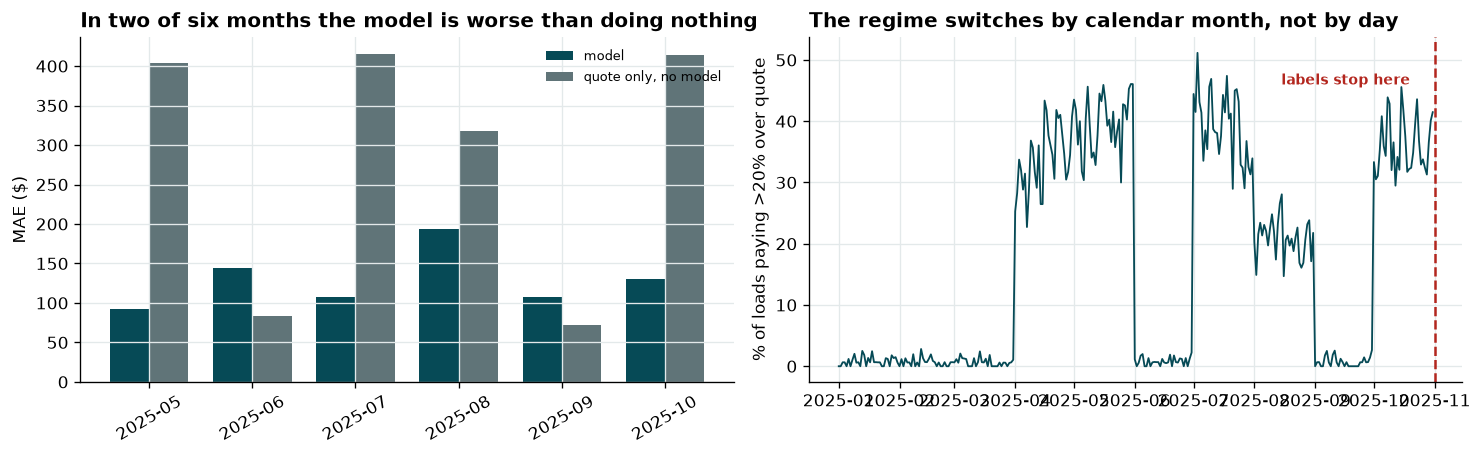

,days in month,days above 20%,mean daily market level
date,,,
2025-01,31,0,0.927
2025-02,28,0,0.996
2025-03,31,0,1.073
2025-04,30,30,1.207
2025-05,31,31,1.301
2025-06,30,0,1.280
2025-07,31,31,1.201
2025-08,31,21,0.982
2025-09,30,0,0.893


correlation, daily market level vs daily share over quote: +0.42


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.9))

positions = np.arange(len(by_month))
width = 0.38
axes[0].bar(positions - width / 2, by_month["model MAE"], width, color=TEAL, label="model")
axes[0].bar(positions + width / 2, by_month["quote-only MAE"], width, color=SLATE,
            label="quote only, no model")
axes[0].set_xticks(positions)
axes[0].set_xticklabels(by_month.index, rotation=30)
axes[0].set_ylabel("MAE ($)")
axes[0].set_title("In two of six months the model is worse than doing nothing",
                  loc="left", fontweight="bold")
axes[0].legend(frameon=False, fontsize=8)

# Is this a daily thing the model could learn, or a monthly switch it cannot see?
daily_share = (train_ratio > 1.2).groupby(train.date).mean() * 100
axes[1].plot(daily_share.index, daily_share, color=TEAL, linewidth=1.1)
axes[1].axvline(pd.Timestamp("2025-11-01"), color=RUST, linestyle="--", linewidth=1.5)
axes[1].annotate("labels stop here", xy=(pd.Timestamp("2025-11-01"), 46),
                 xytext=(-92, 0), textcoords="offset points", color=RUST,
                 fontweight="bold", fontsize=8.5)
axes[1].set_ylabel("% of loads paying >20% over quote")
axes[1].set_title("The regime switches by calendar month, not by day",
                  loc="left", fontweight="bold")
plt.tight_layout()
plt.show()

months = daily_share.index.strftime("%Y-%m")
display(pd.DataFrame({
    "days in month": daily_share.groupby(months).size(),
    "days above 20%": (daily_share > 20).groupby(months).sum(),
    "mean daily market level": train.groupby(train_month).market_index.mean(),
}).round(3))

# Could the model see the regime coming? Only if the market level tracked it.
daily_market = train.groupby("date").market_index.mean()
print(f"correlation, daily market level vs daily share over quote: "
      f"{daily_share.corr(daily_market):+.2f}")

**The training year holds two regimes and they alternate by calendar month.** In January,
February, March, June and September the quote is essentially exact: the median load pays
1.000× and under 1% pay more than 20% over. In April, May, July and October, 34 to 40%
run past it. August is a third thing, active on 21 of its 31 days. The right-hand panel
shows the switch is total: every day of an active month is active, every day of a quiet
month is quiet.

**That is why the model loses to the quote in June and September.** In a quiet month there
is no deviation to predict and the model predicts one anyway: MAE \$144.56 against the
quote's \$82.85 in June, \$107.03 against \$71.75 in September. In the active months it cuts
MAE by 69 to 77%. Pooled, the two net to the 55% cut in §20, and the pooled number hides
both halves.

**Nothing available at prediction time says which regime November and December are in.**
The market level does not: June is quiet at a mean of 1.280 while October is active at
0.957, and the correlation between the daily market level and the daily share running
over quote is only +0.42. A `month` feature would carry it for the ten months in the
training file and be useless for the two that matter, for exactly the reason §14 rejects
`date_ordinal`.

In [29]:
# The model that ships in §25, fitted once here so its bet can be read directly.
final = recurring_model().fit(train)
validation_ratio = final.predict(valid) / (valid.distance * valid.quote_signal)

print(f"median predicted / quote, Nov-Dec  : {np.median(validation_ratio):.4f}")
print(f"share predicted above 1.2 x quote  : {(validation_ratio > 1.2).mean():.1%}")
print(f"same share across the training year: {(train_ratio > 1.2).mean():.1%}")

median predicted / quote, Nov-Dec  : 1.0094
share predicted above 1.2 x quote  : 16.6%
same share across the training year: 17.5%


The model hedges. It predicts the unconditional mixture of the two regimes, because
without knowing which one it is in that is the best it can do. **This is the largest
single risk in the submission and it is invisible in every pooled metric.** If November
and December are quiet, `distance × quote_signal` submitted with no model at all would
score better; if they are active, the model wins by a wide margin. Stated as an open risk
rather than left for a reader to find.

<a id="23"></a>
## 23. Residual diagnostics

A metric table says how large the error is. These say what shape it has, which is what
decides whether one number describes the whole book.

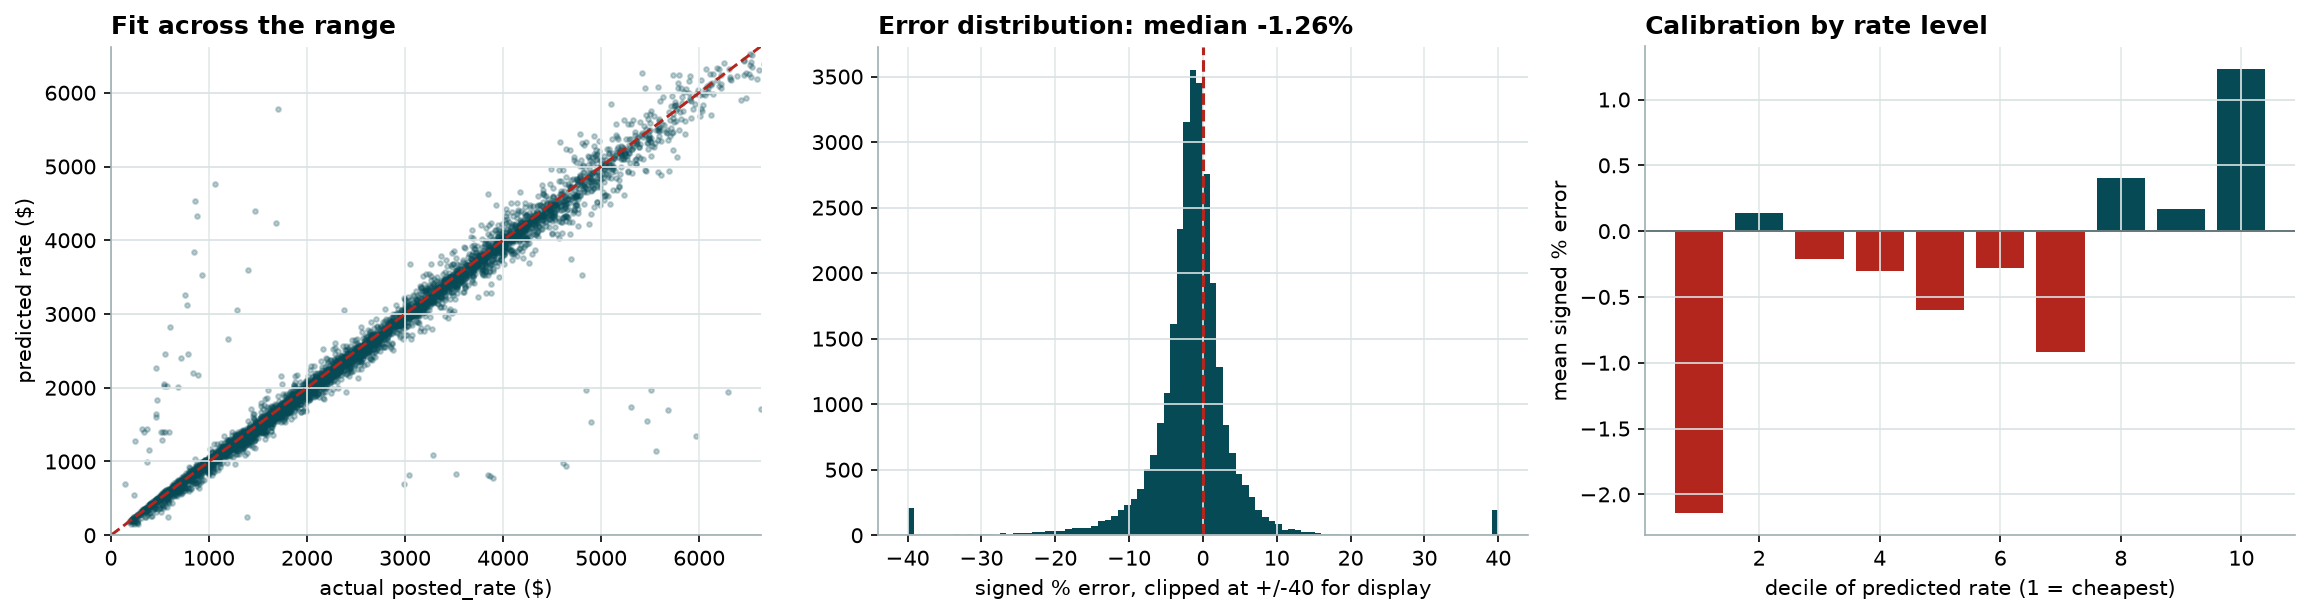

In [30]:
from IPython.display import Image

# NOTE: importing charts selects matplotlib's Agg backend, so this is the last cell that
# could draw inline. Everything after it is written to reports/figures/ and displayed.
from freight_rate.evaluation import charts

Image(str(charts.error_diagnostics(
    pooled.posted_rate, predicted, CONFIG.paths.figures / "error_diagnostics.png",
)))

**Fit.** The bulk hugs the diagonal at every rate level rather than fanning out or
bending, so a single MAE describes the whole rate range: what §22 found varies by month,
not by how dear the load is. The scattered points well below the line are §3's tail,
loads that paid far more than their quote, which nothing in the matrix anticipates.

**Distribution.** The bulk is narrow and its mass sits slightly left of zero, which is
§21's bias made visible.

**Calibration.** The deciles here are of the *predicted* rate rather than the actual, so
the regression-to-the-mean artifact runs the opposite way from the familiar one: a load
the model calls cheapest is on average dearer than the call (−2.1%), and one it calls
dearest is cheaper (+1.2%). The middle eight deciles sit within a point of zero and just
below it, which is §21's bias and nothing more, so the drift is confined to the ends
rather than tilting the whole book.

---

# Part VII. Deliverables

<a id="24"></a>
## 24. The December chart

`december_chart_inputs.csv` carries seven columns and freezes every input except the date:
one lane, 360 miles, Dry Van, 32,000 lb. The model needs coordinates, `market_index` and
`quote_signal`, and each is recovered differently.

| Column | How it is recovered | How exact |
|---|---|---|
| Coordinates | City-name lookup | Exact. Fixed per city across the dataset (§15) |
| `market_index` | Each date's level from `validation.csv`, which covers all 31 December days | ±0.002, because averaging ~157 loads cancels the per-load noise (§5) |
| `quote_signal` | Median over comparable training loads, same equipment and length band | Coarse, and held constant all month |

Holding `quote_signal` constant is deliberate: every bit of movement left in the curve
then comes from the date handling, which is what the chart exists to expose.

,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,NaN
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,NaN
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,NaN


,market input,date encoding,range across the month,distinct values in 31 days
0,constant,ordinal,$0.00,1
1,recovered,ordinal,$4.84,22
2,recovered,recurring,$9.68,30


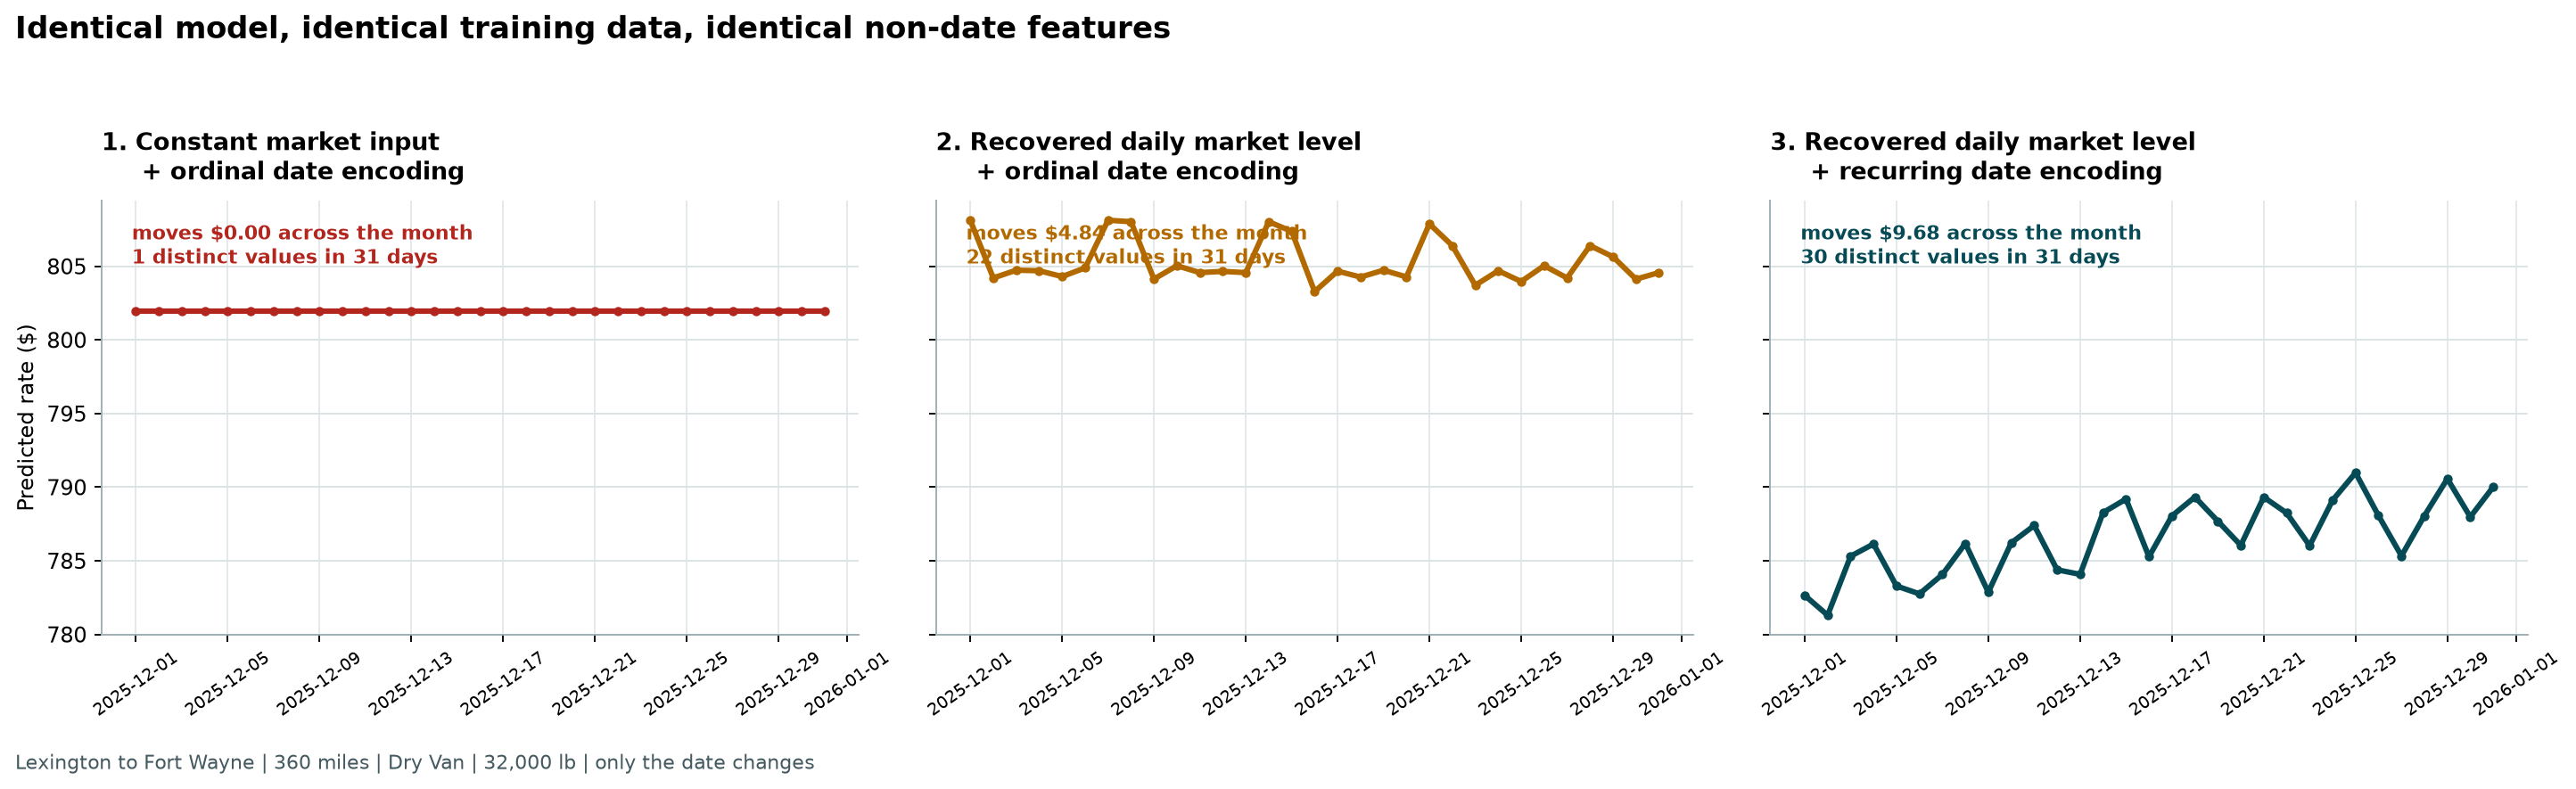

In [31]:
from freight_rate import december as december_module
from freight_rate.cli import DECEMBER_SCENARIOS

raw_december = loading.load_december_inputs()
display(raw_december.head(3))

curves, titles, colours = [], [], []
for constant_market, encoding, colour, title in DECEMBER_SCENARIOS:
    frame = december_module.prepare(
        raw_december, train, valid, market_levels, constant_market=constant_market,
    )
    curves.append(RateModel(encoding, market_levels).fit(train).predict(frame))
    titles.append(title)
    colours.append(colour)

display(pd.DataFrame([
    {"market input": "constant" if constant else "recovered",
     "date encoding": encoding.value,
     "range across the month": f"${values.max() - values.min():,.2f}",
     "distinct values in 31 days": len(np.unique(values.round(2)))}
    for (constant, encoding, _, _), values in zip(DECEMBER_SCENARIOS, curves)
]))

Image(str(charts.december_comparison(
    raw_december["date"], curves, titles, colours,
    CONFIG.paths.figures / "december_encoding_comparison.png",
)))

**The first panel is the failure the chart is built to expose.** One value for the whole
month, because a constant market input leaves an ordinal date encoding with nothing that
varies. Recovering the daily level fixes the flat line; the recurring encoding then moves
on 30 of 31 days.

Read the distinct-value counts as an ordering, not as magnitudes. They have ranked the
three scenarios the same way under every model this repo has run, but the values move a
lot: the middle panel has read 10, 11, 18 and 22 as the estimator changed. The
load-bearing evidence for the encoding is the MAE in §14, not this table.

The dollar ranges are small because the chart freezes `quote_signal`, which carries 81% of
permutation importance. What moves here is the date response with the dominant feature
pinned, which is what the chart isolates and is not a measure of accuracy.

<a id="25"></a>
## 25. `validation_predictions.csv` and the scorer contract

In [32]:
predictions = pd.DataFrame({
    "load_id": valid.load_id,
    "predicted_rate": np.round(final.predict(valid), 2),
})
predictions.to_csv(CONFIG.paths.predictions, index=False)

filled_december = raw_december.copy()
filled_december["predicted_rate"] = np.round(curves[-1], 2)
filled_december["date"] = filled_december["date"].dt.strftime("%Y-%m-%d")
filled_december.to_csv(CONFIG.paths.december_predictions, index=False)

print(f"rows {len(predictions):,} | min ${predictions.predicted_rate.min():,.2f} "
      f"| max ${predictions.predicted_rate.max():,.2f} "
      f"| nulls {int(predictions.predicted_rate.isna().sum())}")
print(f"wrote {CONFIG.paths.predictions.name} and {CONFIG.paths.december_predictions.name}")
display(predictions.head(3))

rows 12,000 | min $172.91 | max $6,841.94 | nulls 0
wrote validation_predictions.csv and december_predictions.csv


,load_id,predicted_rate
0,TE-000001,829.07
1,TE-000002,4719.32
2,TE-000003,5279.60


Both files are written to the repository root, where `score.py`'s documented invocation
expects them. `tests/test_scorer_contract.py` asserts the output satisfies every rule the
scorer checks, because a format rejection scores zero regardless of model quality.

```bash
python score.py --predictions validation_predictions.csv --december-predictions december_predictions.csv
```

**The whole pipeline, in the order this notebook walked it.**

| Stage | Module | Section | CLI command |
|---|---|---|---|
| Read, with schema enforcement | `loading.py` | §1 | every command |
| Repair signs and gaps | `cleaning.py` | §4, §16 | every command |
| Recover the daily market level | `market.py` | §5 | every command |
| Build 15 features in three blocks | `features/` | §11 to §15 | every command |
| Transform the target, fit, predict | `modeling/` | §17, §18 | every command |
| Score the folds | `evaluation/metrics.py` | §14, §19 | `validate` |
| The full panel, segments, diagnostics | `evaluation/report.py` | §20 to §23 | `evaluate` |
| Write the deliverables | `december.py`, `cli.py` | §24, §25 | `december`, `predict` |